# Homework: Denoising Diffusion Models on 2D Toy Data

### Setup (Provided)

In [ ]:
# --- provided ---
!pip install -q -U einops tqdm


In [ ]:
# --- provided ---
%matplotlib inline

import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)


In [ ]:
# --- provided ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


### Part 0 — Dataset (Provided)

**Please use the below dataset**

torch.Size([60000, 2])


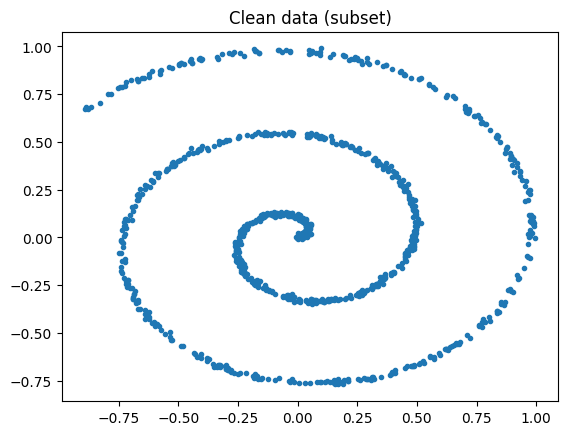

In [ ]:
# --- provided ---
t = np.linspace(0, 15, 60000)
noise = 0.1 * np.random.randn(2, len(t))
y = t * np.sin(t) + noise[0, :]
x = t * np.cos(t) + noise[1, :]
x = x / np.max(x)
y = y / np.max(y)

npdata = np.stack([x, y]).T
np.random.shuffle(npdata)
data = torch.from_numpy(npdata).float()   # shape (60000, 2)

plt.plot(npdata[:1000, 0], npdata[:1000, 1], '.')
plt.title("Clean data (subset)")
print(data.shape)


## Part 1 — Cosine beta schedule (5 pts)


The linear beta schedule can be calculated by the below code:

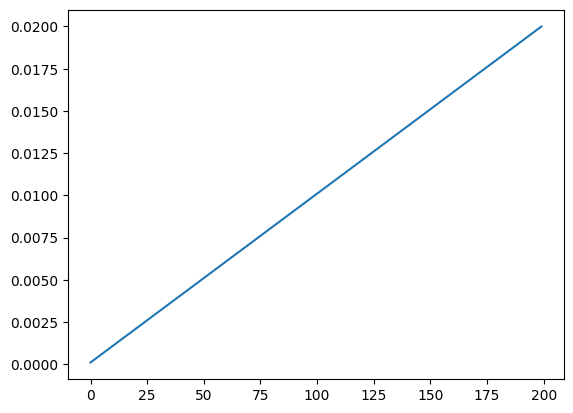

In [ ]:
# --- provided ---

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(timesteps=200)          # swap for linear_beta_schedule(...) to compare
plt.plot(betas)


The linear schedule destroys signal quite quickly. Nichol & Dhariwal (*Improved DDPM*, 2021) propose a cosine schedule that keeps $\bar\alpha_t$ closer to 1 for longer near $t=0$ and near 0 for longer near $t=T$:

$$\bar\alpha_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos\!\left(\frac{t/T + s}{1+s}\cdot\frac{\pi}{2}\right)^{\!2}$$

with small offset $s=0.008$. Betas are then recovered from consecutive $\bar\alpha_t$ values:

$$\beta_t = 1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}, \qquad \text{clipped to } [0.0001,\ 0.999].$$



Your task is to implement the **Cosine beta schedule**

In [ ]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    TODO: implement the cosine noise schedule described above.

    Steps:
      1. Build t = 0, 1, ..., timesteps  (timesteps + 1 points)
      2. Compute f(t) = cos( ((t/timesteps + s) / (1+s)) * pi/2 ) ** 2
      3. Normalize: alphas_cumprod = f(t) / f(0)
      4. Recover betas_t = 1 - alphas_cumprod[t] / alphas_cumprod[t-1] for t=1..timesteps
      5. Clip betas to [0.0001, 0.9999]

    Returns
    -------
    torch.Tensor of shape (timesteps,)
    """
    raise NotImplementedError

**Run the code below and plot the cosine beta schedule**

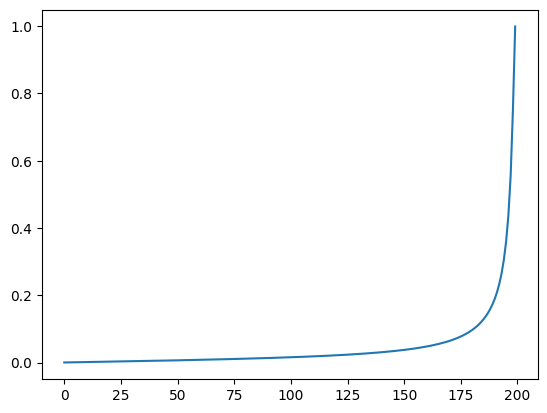

In [ ]:
# --- provided ---

timesteps = 200
betas = cosine_beta_schedule(timesteps)          # swap for linear_beta_schedule(...) to compare
plt.plot(betas)

### Part 2 — Forward diffusion (10 Pts)

**Implement the forward diffusion.**

In [ ]:
def q_sample(x_start, t, noise=None):
    """
    TODO: implement the closed-form forward diffusion step

        x_t = sqrt(alphas_cumprod[t]) * x_start + sqrt(1 - alphas_cumprod[t]) * noise

    Parameters
    ----------
    x_start : torch.Tensor of shape (batch_size, *dims) -- the clean data
    t : torch.Tensor of shape (batch_size,) -- per-example timestep indices
    noise : optional torch.Tensor of the same shape as x_start

    Returns
    -------
    torch.Tensor of the same shape as x_start -- the noised data x_t
    """
    raise NotImplementedError

**Run the code below. It should be able to demonstrate the forward noising process**

torch.Size([60000, 2])
(60000, 2)


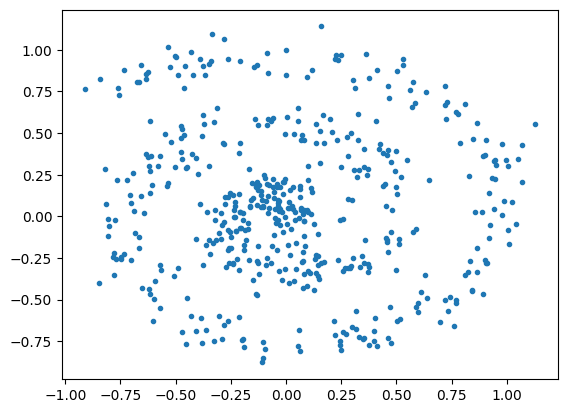

In [ ]:
# --- provided ---

print(data.shape)

t=8
xt = q_sample(data, torch.full((data.shape[0],), t)).numpy()
print(xt.shape)

plt.plot(xt[:500, 0], xt[:500, 1], '.')

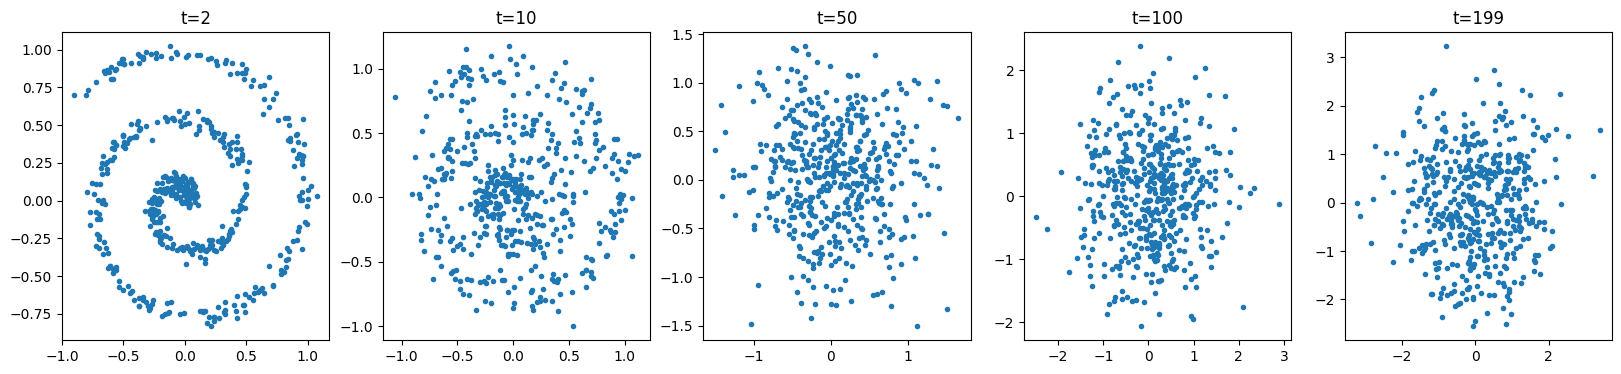

In [ ]:
# --- provided ---

# --- Demonstration of the Forward diffusion ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, tt in zip(axes, [2, 10, 50, 100, 199]):
    xt = q_sample(data, torch.full((data.shape[0],), tt)).numpy()
    ax.plot(xt[:500, 0], xt[:500, 1], '.')
    ax.set_title(f"t={tt}")


### Part 3 — The noise estimation network (Provided)

Below we provide a noise estimation neural network that works well in this problem. Note that the **time is embedded into a vector** and **re-injected at every block**.
Feel free to change the structure and hyperparameters of this neural net!

In [ ]:
# --- provided ---
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class _TimeConditionedBlock(nn.Module):
    """One residual block: time embedding is projected and added back in,
    so every block -- not just the last layer -- sees the noise level."""
    def __init__(self, dim, time_dim):
        super().__init__()
        self.time_proj = nn.Linear(time_dim, dim)
        self.net = nn.Sequential(nn.Linear(dim, dim), nn.GELU())
        self.out = nn.Sequential(nn.Linear(dim, dim), nn.GELU())

    def forward(self, x, t_emb):
        h = self.net(x)
        h = h + self.time_proj(t_emb)
        h = self.out(h)
        return x + h


class DenoiserMLP(nn.Module):
    def __init__(self, data_dim=2, hidden_dim=128, time_dim=64, n_blocks=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        self.in_proj = nn.Linear(data_dim, hidden_dim)
        self.blocks = nn.ModuleList([_TimeConditionedBlock(hidden_dim, time_dim) for _ in range(n_blocks)])
        self.out_proj = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, time):
        t_emb = self.time_mlp(time)
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h, t_emb)
        return self.out_proj(h)


In [ ]:
# --- provided ---

batch_size = 512
dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)

model = DenoiserMLP().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)



Let's plot the structure of this neural net

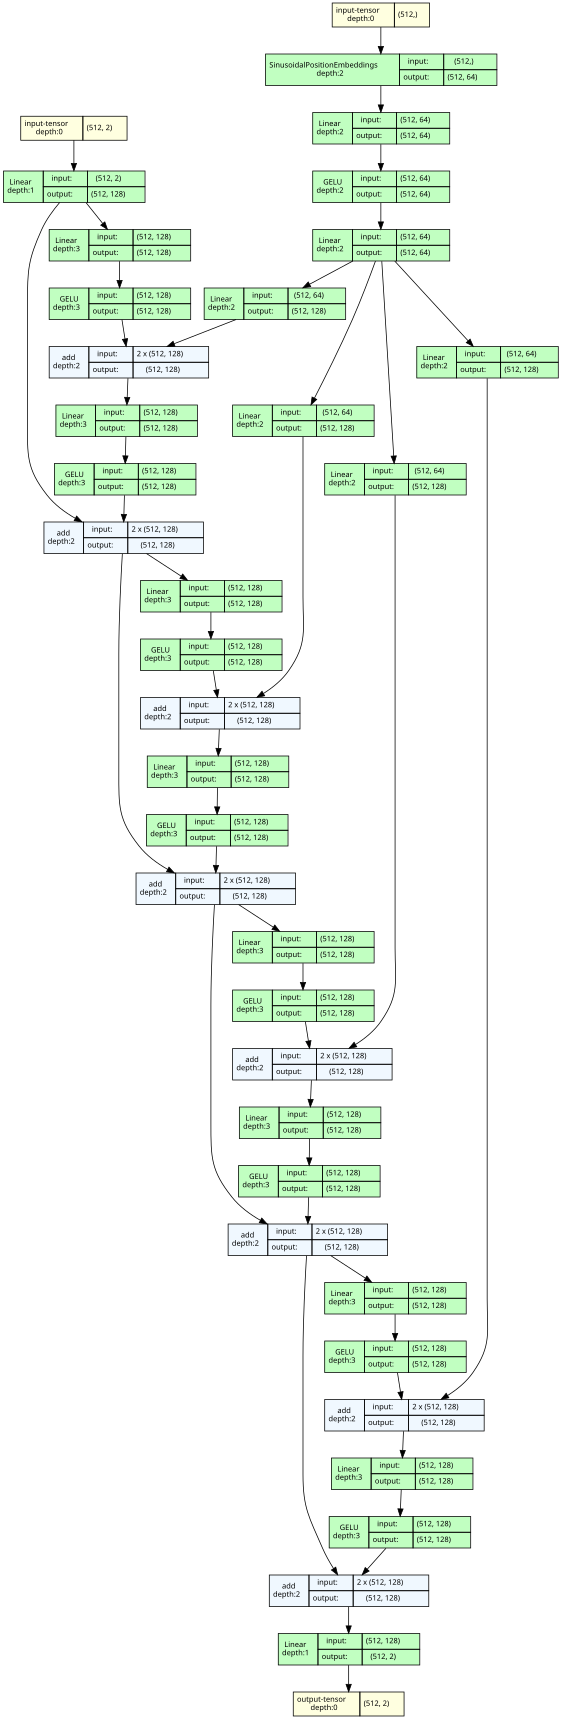

In [ ]:
# --- provided ---

!pip install -q -U torchview
from torchview import draw_graph

# Create dummy batch and t for graph visualization
dummy_batch = data[0:batch_size].to(device) # Use data from the dataset
dummy_t = torch.randint(0, timesteps, (batch_size,), device=device).long()

model_graph = draw_graph(model, input_size=(dummy_batch.shape, dummy_t.shape), save_graph=True)
model_graph.visual_graph


### Part 4 — Implement the noise-prediction training objective (5 points)

In [ ]:
def p_losses(denoise_model, x_start, t, noise=None, loss_type="l2"):
    """
    TODO: implement the noise-prediction training objective.

    Steps:
      1. If `noise` is None, sample it as standard Gaussian noise the same
         shape as x_start
      2. Compute the noised input: x_noisy = q_sample(x_start, t, noise)
      3. Run the model to get its noise prediction: predicted_noise = denoise_model(x_noisy, t)
      4. Compute the loss between the true `noise` and `predicted_noise`: Use e.g.
           - "l2"    -> F.mse_loss
           - "huber" -> F.smooth_l1_loss

    Parameters
    ----------
    denoise_model : nn.Module with signature model(x_noisy, t) -> predicted_noise
    x_start : torch.Tensor of shape (batch_size, *dims) -- the clean data
    t : torch.Tensor of shape (batch_size,) -- per-example timestep indices
    noise : optional torch.Tensor of the same shape as x_start
    loss_type : one of "l1", "l2", "huber"

    Returns
    -------
    A scalar torch.Tensor -- the training loss for this batch.
    """
    raise NotImplementedError


Run the training algorithm.
On Google Colab CPU the training finishes in about 3 minutes 20 seconds

In [ ]:
%%time

# --- provided ---

epochs = 50
losses = []
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        batch_size = batch.shape[0]
        batch = batch.to(device)

        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        loss = p_losses(model, batch, t, loss_type="l2")
        losses.append(loss.item())

        if step % 100 == 0:
            print("Loss:", loss.item())

        loss.backward()
        optimizer.step()

epoch: 0
Loss: 1.0932401418685913
Loss: 0.3195424973964691
epoch: 1
Loss: 0.3174704611301422
Loss: 0.3429630994796753
epoch: 2
Loss: 0.2892194986343384
Loss: 0.31556960940361023
epoch: 3
Loss: 0.31704217195510864
Loss: 0.27025488018989563
epoch: 4
Loss: 0.3012502193450928
Loss: 0.2809179425239563
epoch: 5
Loss: 0.33035165071487427
Loss: 0.3091192841529846
epoch: 6
Loss: 0.298811137676239
Loss: 0.31073862314224243
epoch: 7
Loss: 0.29913216829299927
Loss: 0.302071750164032
epoch: 8
Loss: 0.283609002828598
Loss: 0.3218097388744354
epoch: 9
Loss: 0.2918078899383545
Loss: 0.2956714928150177
epoch: 10
Loss: 0.3208608627319336
Loss: 0.2824857532978058
epoch: 11
Loss: 0.2971870005130768
Loss: 0.263398677110672
epoch: 12
Loss: 0.3054020404815674
Loss: 0.3320707082748413
epoch: 13
Loss: 0.3703076243400574
Loss: 0.26698145270347595
epoch: 14
Loss: 0.30141210556030273
Loss: 0.29403460025787354
epoch: 15
Loss: 0.28760385513305664
Loss: 0.2951425015926361
epoch: 16
Loss: 0.28221407532691956
Loss: 0.

**Plot the training losses**

Text(0, 0.5, 'loss')

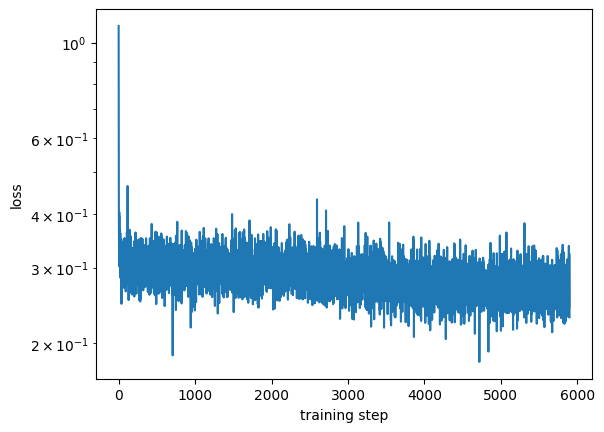

In [ ]:
# --- provided ---
plt.plot(losses)
plt.yscale('log')
plt.xlabel('training step')
plt.ylabel('loss')


### Part 5 — Implement the reverse diffusion for sampling (10 points)

In [ ]:
@torch.no_grad()
def p_sample_loop(model, shape):
    """
    TODO: implement the full reverse diffusion process, from pure noise to a
    generated sample.

    Steps:
      1. Start from x_T ~ N(0, I)
      2. Iterate t from timesteps - 1 down to 0 (inclusive). At each step:
           Call a function that runs one step back in time

    Parameters
    ----------
    model : nn.Module with signature model(x, t) -> predicted_noise
    shape : tuple, e.g. (batch_size, data_dim) -- shape of the samples to generate

    Returns
    -------
    imgs : list of numpy arrays, each of shape `shape` -- the sample trajectory
    from x_T (imgs[0]) down to x_0 (imgs[-1])
    """
    raise NotImplementedError




### Part 6 — Generate samples (Provided)

sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Generated samples')

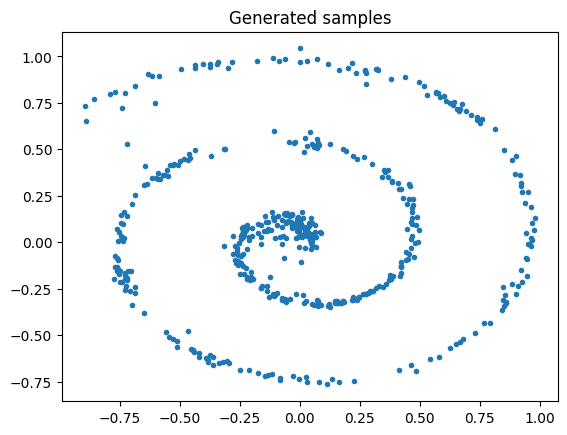

In [ ]:
# --- provided ---
@torch.no_grad()
def sample(model, batch_size=500):
    return p_sample_loop(model, shape=(batch_size, 2))

samples = sample(model, batch_size=500)
snapshot = samples[-1].squeeze()
plt.plot(snapshot[:, 0], snapshot[:, 1], '.')
plt.title("Generated samples")



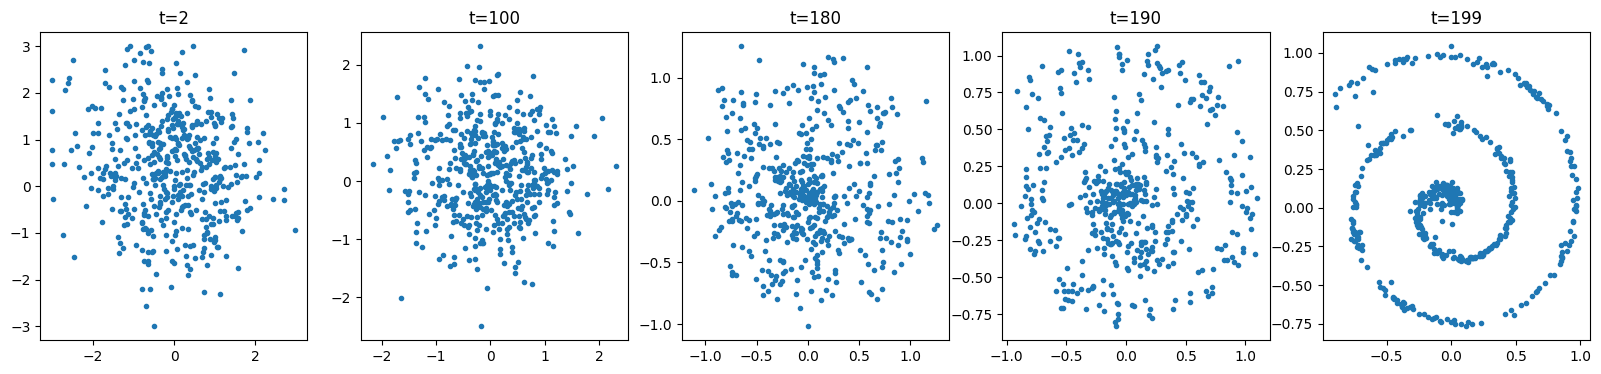

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, tt in zip(axes, [2, 100, 180, 190, 199]):
    xt = samples[tt].squeeze()
    ax.plot(xt[:, 0], xt[:, 1], '.')
    ax.set_title(f"t={tt}")